# Demo completa Sudoku tramite archivio persistente

Questo notebook usa `sudoku_archive.py` come unica interfaccia principale per i dati.
Le analisi `deep`, `profile` e `superficial` vengono salvate in varianti distinte,
quindi un risultato già calcolato può essere riutilizzato nelle esecuzioni successive.

Il flusso verifica:

1. elenco, selezione, salvataggio e caricamento dei Sudoku;
2. analisi persistenti nelle tre modalità;
3. cache in memoria e caricamento da disco;
4. equivalenza della catena risolutiva fra le modalità;
5. dataframe e visualizzazioni aggiornate;
6. quattro heatmap principali;
7. confronto fra conclusioni, risultati distinti e prove;
8. presenza delle varianti nell archivio.

La modalità canonica e predefinita resta `deep`.


## 0. Configurazione

Per riutilizzare tutto ciò che è già stato analizzato, lascia
`FORCE_RECALCULATION = False`.


In [1]:
CREATE_NEW_PUZZLE = False
TARGET_CLUES = 30

SELECTION_METHOD = "latest"
SELECTION_NUMBER = 20

FORCE_RECALCULATION = False
PROFILE_DIFFICULTY_WINDOW = 1.0

RUN_ALL_METRIC_HEATMAPS = True
RUN_ALL_SCALE_HEATMAPS = True
RUN_TECHNIQUE_DETAIL_HEATMAP = True

RUN_ARCHIVE_BATCH = False
ARCHIVE_BATCH_LIMIT = 10


## 1. Import e ricaricamento dei moduli


In [2]:
import importlib
import inspect
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import sudoku_techniques as st
import sudoku_solver as ss
import sudoku_archive as sa
import sudoku_visualization as sv
import sudoku_generator as sg

importlib.invalidate_caches()
st = importlib.reload(st)
ss = importlib.reload(ss)
sa = importlib.reload(sa)
sv = importlib.reload(sv)
sg = importlib.reload(sg)

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)

print("Moduli caricati.")
print("ANALYSIS_VERSION:", sa.ANALYSIS_VERSION)
print("Modalità predefinita archivio:", sa.DEFAULT_ANALYSIS_MODE)


Moduli caricati.
ANALYSIS_VERSION: 9
Modalità predefinita archivio: deep


## 2. Controllo delle nuove interfacce

Il notebook richiede la versione dell archivio che distingue le varianti di analisi.


In [3]:
archive_signature = inspect.signature(sa.analyse_puzzle_cached)
load_signature = inspect.signature(sa.load_analysis)

required_cached_parameters = {
    "analysis_mode",
    "profile_difficulty_window",
    "force",
}
required_load_parameters = {
    "analysis_mode",
    "profile_difficulty_window",
}

missing_cached = required_cached_parameters - set(archive_signature.parameters)
missing_load = required_load_parameters - set(load_signature.parameters)

assert not missing_cached, (
    "sudoku_archive.py non aggiornato. Parametri mancanti in "
    f"analyse_puzzle_cached: {sorted(missing_cached)}"
)
assert not missing_load, (
    "sudoku_archive.py non aggiornato. Parametri mancanti in "
    f"load_analysis: {sorted(missing_load)}"
)
assert sa.ANALYSIS_VERSION >= 8, (
    "Incrementa ANALYSIS_VERSION per invalidare le vecchie analisi."
)

print("Interfacce archivio aggiornate: OK")
print("analyse_puzzle_cached", archive_signature)
print("load_analysis", load_signature)


Interfacce archivio aggiornate: OK
analyse_puzzle_cached (puzzle, name=None, metadata=None, force=False, analysis_mode='deep', profile_difficulty_window=None, max_steps=10000, verbose=False)
load_analysis (reference, analysis_mode='deep', profile_difficulty_window=None)


## 3. Utility del notebook


In [4]:
def timed_call(function, *args, **kwargs):
    start = time.perf_counter()
    result = function(*args, **kwargs)
    return result, time.perf_counter() - start


def chain_signature(analysis):
    return [
        (
            move["technique"],
            float(move["difficulty"]),
            tuple(sorted(tuple(item) for item in move.get("placements", []))),
            tuple(sorted(tuple(item) for item in move.get("eliminations", []))),
        )
        for move in analysis.get("chain", [])
    ]


def validate_analysis(analysis, expected_mode, expected_window=None):
    assert analysis["analysis_mode"] == expected_mode

    if expected_mode == "profile":
        assert abs(
            float(analysis["profile_difficulty_window"])
            - float(expected_window)
        ) <= 1e-12
    else:
        assert analysis.get("profile_difficulty_window") is None

    for step_index, step in enumerate(analysis.get("chain", []), start=1):
        assert "availability" in step, (
            f"Step {step_index}: availability mancante."
        )
        assert "frontier" in step["availability"]
        assert "n_conclusions" in step
        assert "n_best_conclusions" in step
        assert "n_proofs" in step

    return True


def analysis_row(analysis, elapsed=None):
    chain = analysis.get("chain", [])
    grading = analysis.get("grading", {})
    scanned = [
        step.get("analysis_scope", {}).get("scanned_function_count")
        for step in chain
    ]
    scanned = [value for value in scanned if value is not None]

    return {
        "modalita": analysis.get("analysis_mode"),
        "finestra_profile": analysis.get("profile_difficulty_window"),
        "tempo_s": round(elapsed, 5) if elapsed is not None else None,
        "stato": analysis.get("status"),
        "step": len(chain),
        "difficolta_massima": grading.get("max_difficulty"),
        "difficolta_percepita": grading.get("perceived_difficulty"),
        "funzioni_medie_scandite": (
            round(float(np.mean(scanned)), 2)
            if scanned
            else None
        ),
        "conclusioni_osservate": sum(
            int(step.get("n_conclusions", 0))
            for step in chain
        ),
        "conclusioni_minime": sum(
            int(step.get("n_best_conclusions", 0))
            for step in chain
        ),
        "risultati_distinti": sum(
            int(step.get("n_distinct_outcomes", 0))
            for step in chain
        ),
        "prove": sum(
            int(step.get("n_proofs", 0))
            for step in chain
        ),
    }


def generate_demo_puzzle(target_clues, rng):
    candidates = [
        getattr(sg, "generate_unique_puzzle", None),
        getattr(sg, "generate_sudoku", None),
    ]
    candidates = [function for function in candidates if callable(function)]

    if not candidates:
        raise AttributeError(
            "Non trovo generate_unique_puzzle o generate_sudoku."
        )

    function = candidates[0]
    parameters = inspect.signature(function).parameters
    kwargs = {}

    for name in ("target_clues", "clues", "n_clues"):
        if name in parameters:
            kwargs[name] = target_clues
            break

    if "rng" in parameters:
        kwargs["rng"] = rng
    elif "seed" in parameters:
        kwargs["seed"] = rng.randrange(1, 10**9)

    result = function(**kwargs)

    if isinstance(result, dict):
        puzzle = next(
            result[key]
            for key in ("puzzle", "grid", "sudoku")
            if result.get(key) is not None
        )
    elif isinstance(result, tuple):
        puzzle = result[0]
    else:
        puzzle = result

    return np.asarray(puzzle, dtype=int).reshape(9, 9), function.__name__


## 4. Stato corrente dell archivio

`list_sudokus` espone anche le varianti già disponibili per ogni Sudoku.


In [5]:
archive_rows = sa.list_sudokus(
    number=SELECTION_NUMBER,
    method=SELECTION_METHOD,
)
archive_dataframe = pd.DataFrame(archive_rows)

display(archive_dataframe)
print("Sudoku trovati:", len(archive_rows))


,id,name,clues,analysed,analysed_deep,analysed_profile,analysed_superficial,analysis_modes,analysis_variants,created_at,updated_at,max_difficulty,max_level,score,workload_score,perceived_difficulty,max_perceived_step,n_steps,hardest_steps,nontrivial_steps,advanced_steps
0,2bda79ebfd83a5879aa2,coach_ve_9,36,True,True,False,False,[deep],[deep],2026-07-16T14:30:02.649407+00:00,2026-07-19T13:16:12.526328+00:00,1.2,1,0,0,1.661741,-0.698970,45,25,0,0
1,5d7e3809ac74f73a7480,coach_ve_8,32,True,True,False,False,[deep],[deep],2026-07-16T14:29:49.687740+00:00,2026-07-19T13:16:00.890119+00:00,1.2,1,0,0,1.689383,-0.698970,49,29,0,0
2,36a1a94d5e4fbfe84a00,coach_ve_7,30,True,True,False,False,[deep],[deep],2026-07-16T14:29:27.125271+00:00,2026-07-19T13:15:42.505104+00:00,1.2,1,0,0,1.733776,-0.698970,51,30,0,0
3,8e48c36993715ebae948,coach_ve_6,31,True,True,False,False,[deep],[deep],2026-07-16T14:29:15.438884+00:00,2026-07-19T13:15:20.789497+00:00,1.2,1,0,0,1.783096,-0.649485,50,30,0,0
4,fd592c13776eac1c936d,coach_ve_5,32,True,True,False,False,[deep],[deep],2026-07-16T14:28:12.613087+00:00,2026-07-19T13:14:55.826320+00:00,1.2,1,0,0,1.758672,-0.698970,49,28,0,0
5,ee63aa8db1013404504c,coach_ve_4,31,True,True,False,False,[deep],[deep],2026-07-16T14:28:01.231610+00:00,2026-07-19T13:14:30.518992+00:00,1.2,1,0,0,1.715444,-0.698970,50,30,0,0
6,160ec3474f6ea13f435e,coach_ve_3,36,True,True,False,False,[deep],[deep],2026-07-16T14:27:51.792455+00:00,2026-07-19T13:14:11.284332+00:00,1.2,1,0,0,1.652887,-0.649485,45,24,0,0
7,1273e79691bef8e700e4,coach_ve_2,48,True,True,False,False,[deep],[deep],2026-07-16T14:27:41.741607+00:00,2026-07-19T13:13:57.805961+00:00,1.2,1,0,0,1.457473,-0.698970,33,13,0,0
8,2d87b4176256947bd946,coach_ve_14,32,True,True,False,False,[deep],[deep],2026-07-16T14:31:41.332389+00:00,2026-07-19T13:13:53.712222+00:00,1.2,1,0,0,1.721136,-0.698970,49,28,0,0
9,497d063d78d353d0fb31,coach_ve_13,36,True,True,False,False,[deep],[deep],2026-07-16T14:31:21.302550+00:00,2026-07-19T13:13:33.455884+00:00,1.2,1,0,0,1.647531,-0.698970,45,26,0,0


Sudoku trovati: 20


## 6. Analisi persistenti nelle tre modalità

Tutte le chiamate passano da `analyse_puzzle_cached`. Se il risultato corrente
esiste già su disco, non viene ricalcolato.


In [10]:
analysis_specs = {
    "deep": {},
    "profile": {
        "profile_difficulty_window": PROFILE_DIFFICULTY_WINDOW,
    },
    "superficial": {},
}

mode_results = {}
mode_times = {}

for mode, extra_kwargs in analysis_specs.items():
    result, elapsed = timed_call(
        sa.analyse_puzzle_cached,
        puzzle_reference,
        analysis_mode=mode,
        force=FORCE_RECALCULATION,
        **extra_kwargs,
    )

    validate_analysis(
        result,
        expected_mode=mode,
        expected_window=(
            PROFILE_DIFFICULTY_WINDOW
            if mode == "profile"
            else None
        ),
    )

    mode_results[mode] = result
    mode_times[mode] = elapsed

comparison_dataframe = pd.DataFrame([
    analysis_row(mode_results[mode], mode_times[mode])
    for mode in ("deep", "profile", "superficial")
])

display(comparison_dataframe)


,modalita,finestra_profile,tempo_s,stato,step,difficolta_massima,difficolta_percepita,funzioni_medie_scandite,conclusioni_osservate,conclusioni_minime,risultati_distinti,prove
0,deep,NaN,0.00197,solved,45,1.2,1.661741,42.00,2112,178,4108,6370
1,profile,1.0,0.00183,solved,45,1.2,1.661741,4.00,1385,178,1102,1380
2,superficial,NaN,0.00177,solved,45,1.2,1.661741,1.56,287,178,287,436


## 7. Invarianza della catena risolutiva

La modalità cambia l inventario raccolto, non la mossa scelta.


In [11]:
deep_signature = chain_signature(mode_results["deep"])

for mode in ("profile", "superficial"):
    same_chain = chain_signature(mode_results[mode]) == deep_signature
    same_grid = np.array_equal(
        mode_results[mode]["solved_grid"],
        mode_results["deep"]["solved_grid"],
    )

    print(mode, "catena identica:", same_chain)
    print(mode, "griglia finale identica:", same_grid)

    assert same_chain
    assert same_grid


profile catena identica: True
profile griglia finale identica: True
superficial catena identica: True
superficial griglia finale identica: True


## 8. Verifica della cache in memoria

Ogni variante deve avere una propria voce e restituire lo stesso oggetto Python.


In [12]:
for mode, extra_kwargs in analysis_specs.items():
    cached_result, elapsed = timed_call(
        sa.analyse_puzzle_cached,
        puzzle_reference,
        analysis_mode=mode,
        force=False,
        **extra_kwargs,
    )

    print(
        mode,
        "stesso oggetto:",
        cached_result is mode_results[mode],
        "tempo:",
        round(elapsed, 6),
        "s",
    )

    assert cached_result is mode_results[mode]


deep stesso oggetto: True tempo: 0.002139 s
profile stesso oggetto: True tempo: 0.001805 s
superficial stesso oggetto: True tempo: 0.001329 s


## 9. Verifica del caricamento da disco

Il modulo archivio viene ricaricato per svuotare la cache in memoria. Le tre
varianti vengono poi lette con `load_analysis`.


In [13]:
sa = importlib.reload(sa)
disk_results = {}

for mode, extra_kwargs in analysis_specs.items():
    result, elapsed = timed_call(
        sa.load_analysis,
        puzzle_reference,
        analysis_mode=mode,
        **extra_kwargs,
    )

    validate_analysis(
        result,
        expected_mode=mode,
        expected_window=(
            PROFILE_DIFFICULTY_WINDOW
            if mode == "profile"
            else None
        ),
    )

    disk_results[mode] = result

    print(
        mode,
        "caricato da disco in",
        round(elapsed, 6),
        "s",
    )

    assert chain_signature(result) == deep_signature

mode_results = disk_results


deep caricato da disco in 0.01195 s
profile caricato da disco in 0.02463 s
superficial caricato da disco in 0.020937 s


## 10. Varianti registrate nell archivio


In [14]:
updated_rows = sa.list_sudokus(method="latest")
updated_dataframe = pd.DataFrame(updated_rows)
current_row = updated_dataframe[
    updated_dataframe["id"] == puzzle_reference
]

display(current_row)

assert not current_row.empty
assert bool(current_row.iloc[0]["analysed_deep"])
assert bool(current_row.iloc[0]["analysed_profile"])
assert bool(current_row.iloc[0]["analysed_superficial"])

print(
    "Varianti:",
    current_row.iloc[0]["analysis_variants"],
)


,id,name,clues,analysed,analysed_deep,analysed_profile,analysed_superficial,analysis_modes,analysis_variants,created_at,updated_at,max_difficulty,max_level,score,workload_score,perceived_difficulty,max_perceived_step,n_steps,hardest_steps,nontrivial_steps,advanced_steps
0,2bda79ebfd83a5879aa2,coach_ve_9,36,True,True,True,True,"[deep, profile, superficial]","[deep, profile_1, superficial]",2026-07-16T14:30:02.649407+00:00,2026-07-19T13:27:05.404831+00:00,1.2,1,0,0,1.661741,-0.69897,45,25,0,0


Varianti: ['deep', 'profile_1', 'superficial']


## 11. Griglia risolta e catena di difficoltà


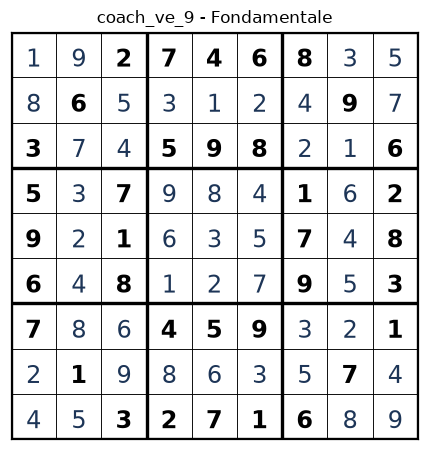

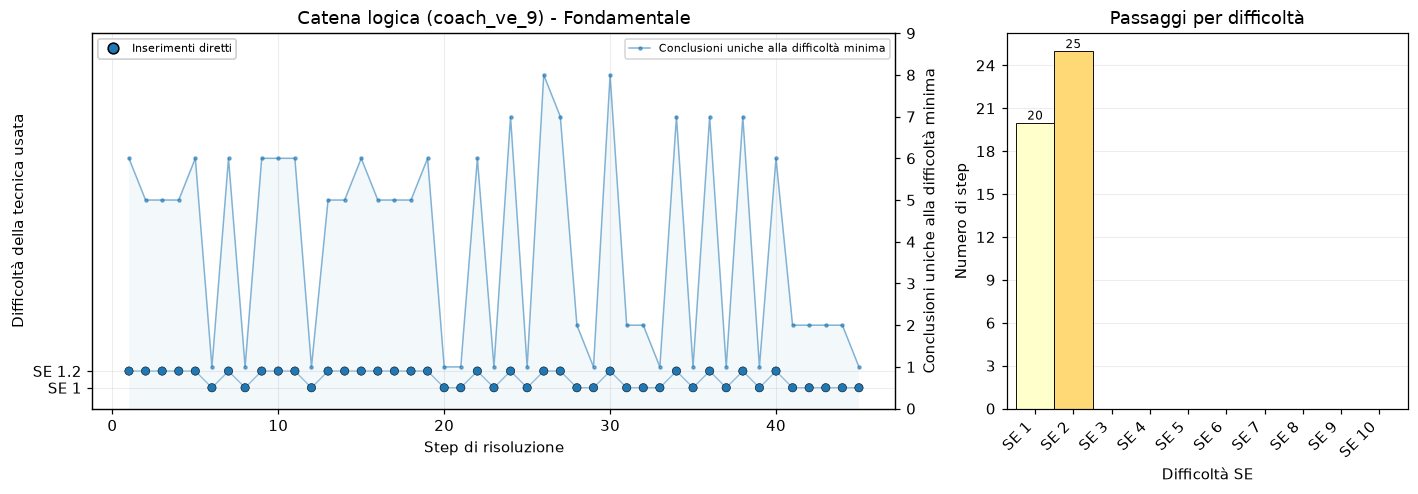

(<Figure size 1430x506 with 3 Axes>,
 (<Axes: title={'center': 'Catena logica (coach_ve_9) - Fondamentale'}, xlabel='Step di risoluzione', ylabel='Difficoltà della tecnica usata'>,
  <Axes: title={'center': 'Passaggi per difficoltà'}, xlabel='Difficoltà SE', ylabel='Numero di step'>,
  <Axes: ylabel='Conclusioni uniche alla difficoltà minima'>))

In [15]:
deep_result = mode_results["deep"]

sv.draw_grid(
    deep_result["solved_grid"],
    given_mask=(deep_result["original"] != 0),
    title=(
        f"{deep_result['name']} - "
        f"{deep_result['grading']['label']}"
    ),
)
plt.show()

sv.plot_difficulty_chain(deep_result)


## 12. Passaggio più difficile


,step,tecnica,famiglia,strategia,difficolta,conclusioni,conclusioni_minime,risultati_distinti,prove,modalita_analisi,descrizione
0,1,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,110,6,209,279,deep,"Nel box che contiene R3C2, il numero 7 puo com..."
1,2,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,108,5,190,259,deep,"Nel box che contiene R2C1, il numero 8 puo com..."
2,3,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,103,5,185,245,deep,"Nel box che contiene R1C1, il numero 1 puo com..."
3,4,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,101,5,184,237,deep,"Nel box che contiene R1C2, il numero 9 puo com..."
4,5,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,98,6,182,236,deep,"Nel box che contiene R2C3, il numero 5 puo com..."
6,7,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,90,6,175,236,deep,"Nel box che contiene R3C8, il numero 1 puo com..."
8,9,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,84,6,154,221,deep,"Nel box che contiene R2C9, il numero 7 puo com..."
9,10,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,83,6,156,219,deep,"Nel box che contiene R2C7, il numero 4 puo com..."
10,11,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,80,6,154,214,deep,"Nel box che contiene R1C8, il numero 3 puo com..."
12,13,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,74,5,137,192,deep,"Nel box che contiene R6C6, il numero 7 puo com..."


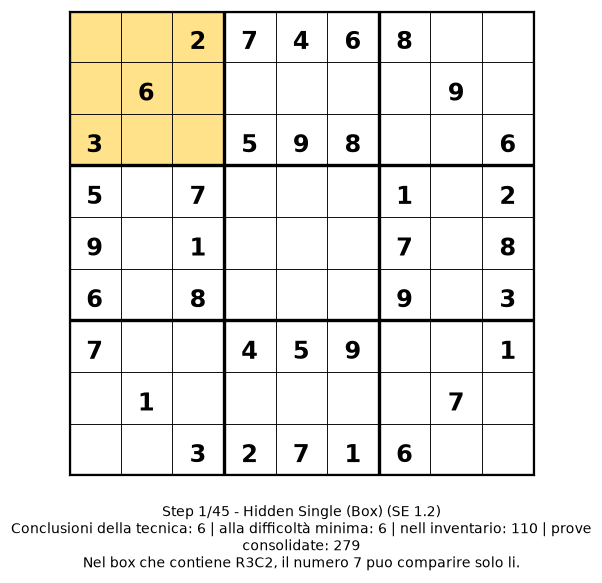

In [16]:
chain_dataframe = sv.summary_dataframe(deep_result)

if chain_dataframe.empty:
    print("Nessun passaggio registrato.")
else:
    hardest_rows = (
        chain_dataframe
        .sort_values(
            ["difficolta", "step"],
            ascending=[False, True],
        )
        .head(10)
    )
    display(hardest_rows)

    hardest_index = int(hardest_rows.iloc[0]["step"]) - 1
    sv.draw_step(deep_result, hardest_index)


## 13. Catena completa e frequenza delle tecniche


In [17]:
display(chain_dataframe)

if not chain_dataframe.empty:
    technique_counts = (
        chain_dataframe
        .groupby(
            ["strategia", "famiglia", "tecnica"],
            dropna=False,
        )
        .agg(
            numero_step=("step", "count"),
            difficolta_massima=("difficolta", "max"),
            conclusioni=("conclusioni", "sum"),
            risultati_distinti=("risultati_distinti", "sum"),
            prove=("prove", "sum"),
        )
        .reset_index()
        .sort_values(
            ["difficolta_massima", "numero_step"],
            ascending=[False, False],
        )
    )

    display(technique_counts)


,step,tecnica,famiglia,strategia,difficolta,conclusioni,conclusioni_minime,risultati_distinti,prove,modalita_analisi,descrizione
0,1,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,110,6,209,279,deep,"Nel box che contiene R3C2, il numero 7 puo com..."
1,2,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,108,5,190,259,deep,"Nel box che contiene R2C1, il numero 8 puo com..."
2,3,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,103,5,185,245,deep,"Nel box che contiene R1C1, il numero 1 puo com..."
3,4,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,101,5,184,237,deep,"Nel box che contiene R1C2, il numero 9 puo com..."
4,5,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,98,6,182,236,deep,"Nel box che contiene R2C3, il numero 5 puo com..."
5,6,Last Value,Inserimenti diretti,Tecniche elementari,1.0,94,1,172,237,deep,R3C3 è l ultima cella vuota del box: deve cont...
6,7,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,90,6,175,236,deep,"Nel box che contiene R3C8, il numero 1 puo com..."
7,8,Last Value,Inserimenti diretti,Tecniche elementari,1.0,88,1,169,231,deep,R3C7 è l ultima cella vuota del row: deve cont...
8,9,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,84,6,154,221,deep,"Nel box che contiene R2C9, il numero 7 puo com..."
9,10,Hidden Single (Box),Inserimenti diretti,Tecniche elementari,1.2,83,6,156,219,deep,"Nel box che contiene R2C7, il numero 4 puo com..."


,strategia,famiglia,tecnica,numero_step,difficolta_massima,conclusioni,risultati_distinti,prove
0,Tecniche elementari,Inserimenti diretti,Hidden Single (Box),25,1.2,1513,2884,4289
1,Tecniche elementari,Inserimenti diretti,Last Value,20,1.0,599,1224,2081


## 14. Le quattro heatmap principali

Le viste `deep` usano l intero inventario salvato. Le viste `superficial`
usano la sola frontiera alla difficoltà minima dello stesso risultato deep.


depth=deep, view=extended


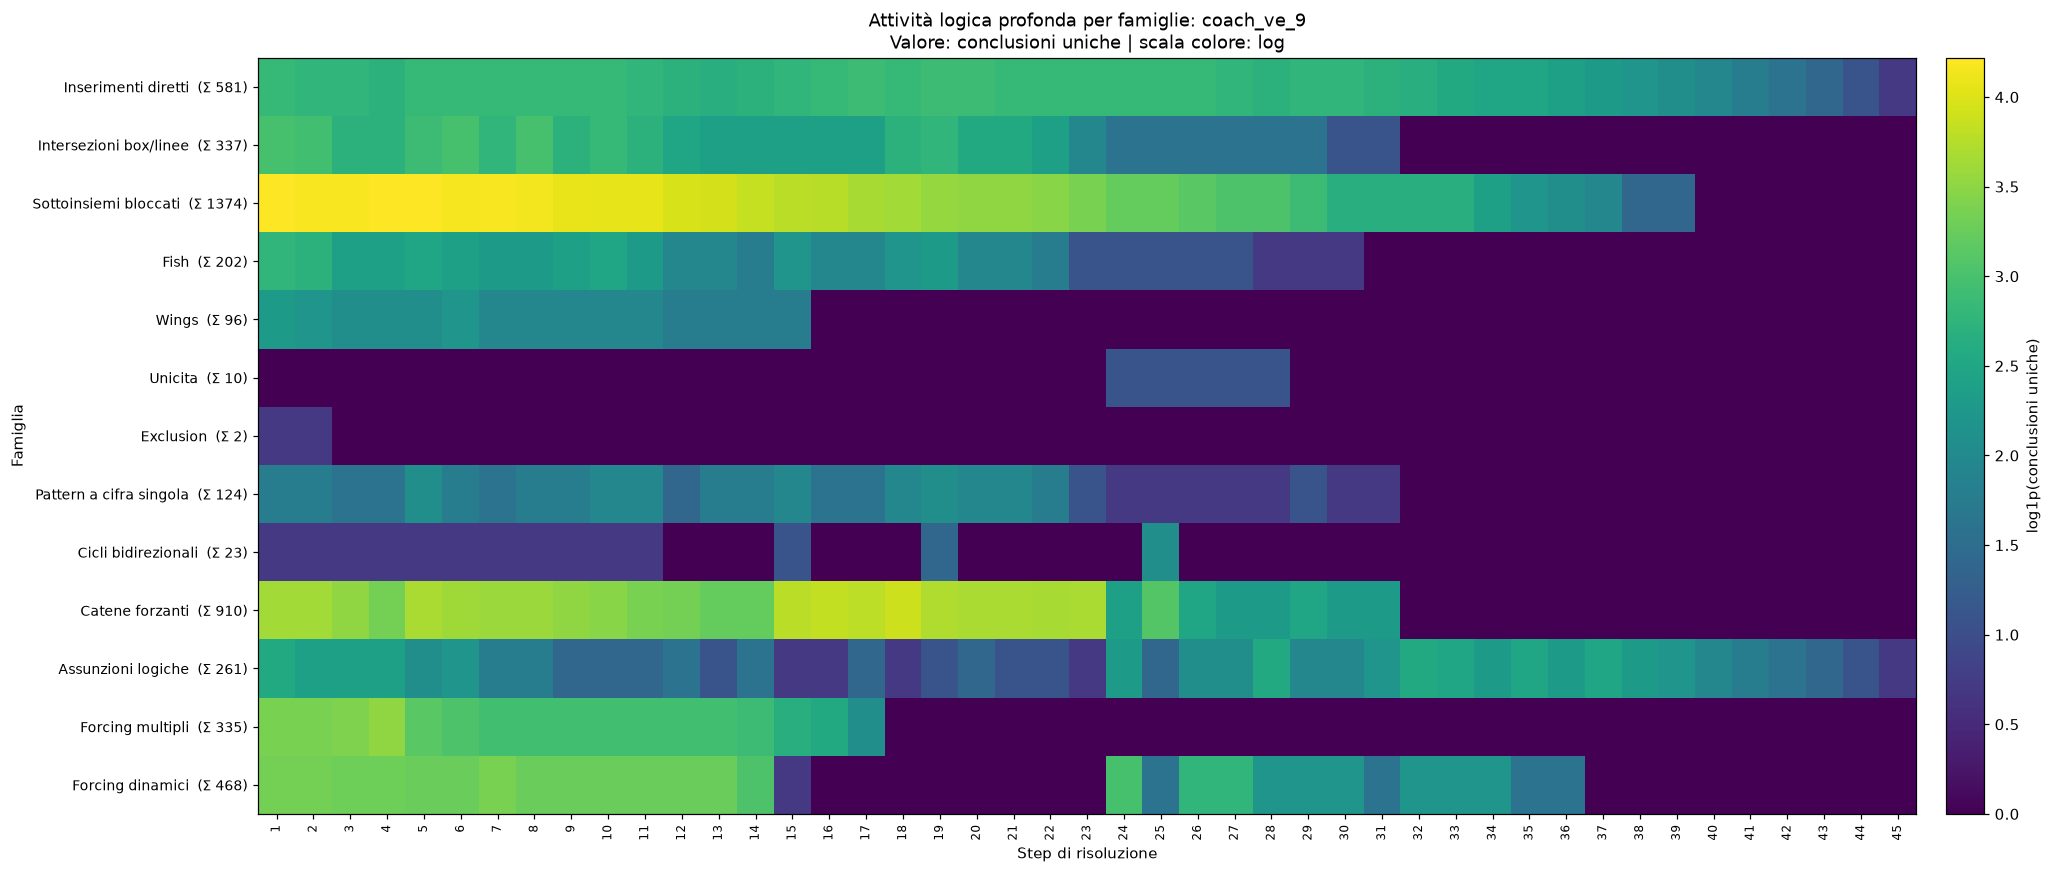

depth=deep, view=compact


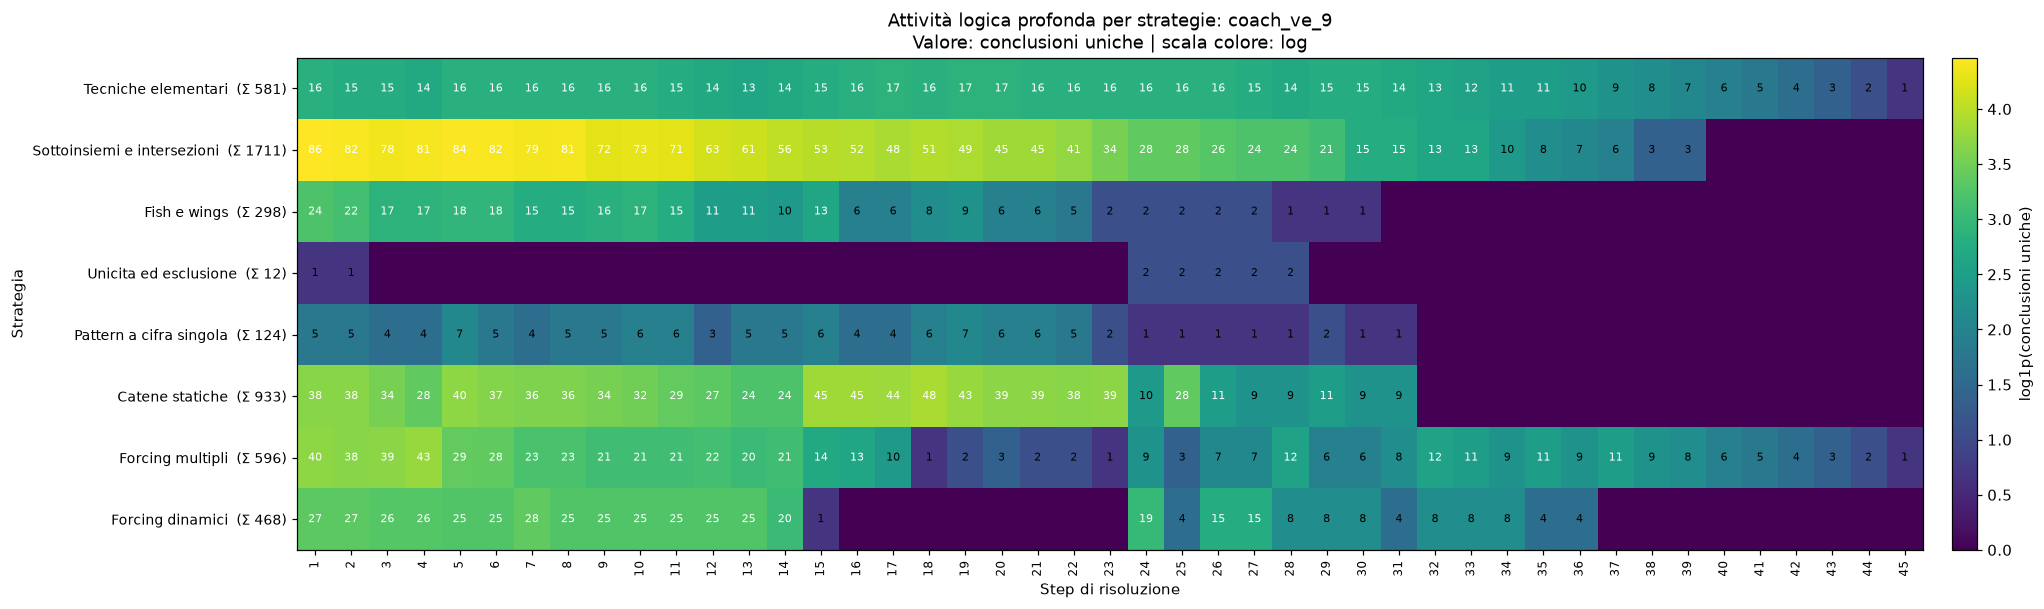

depth=superficial, view=extended


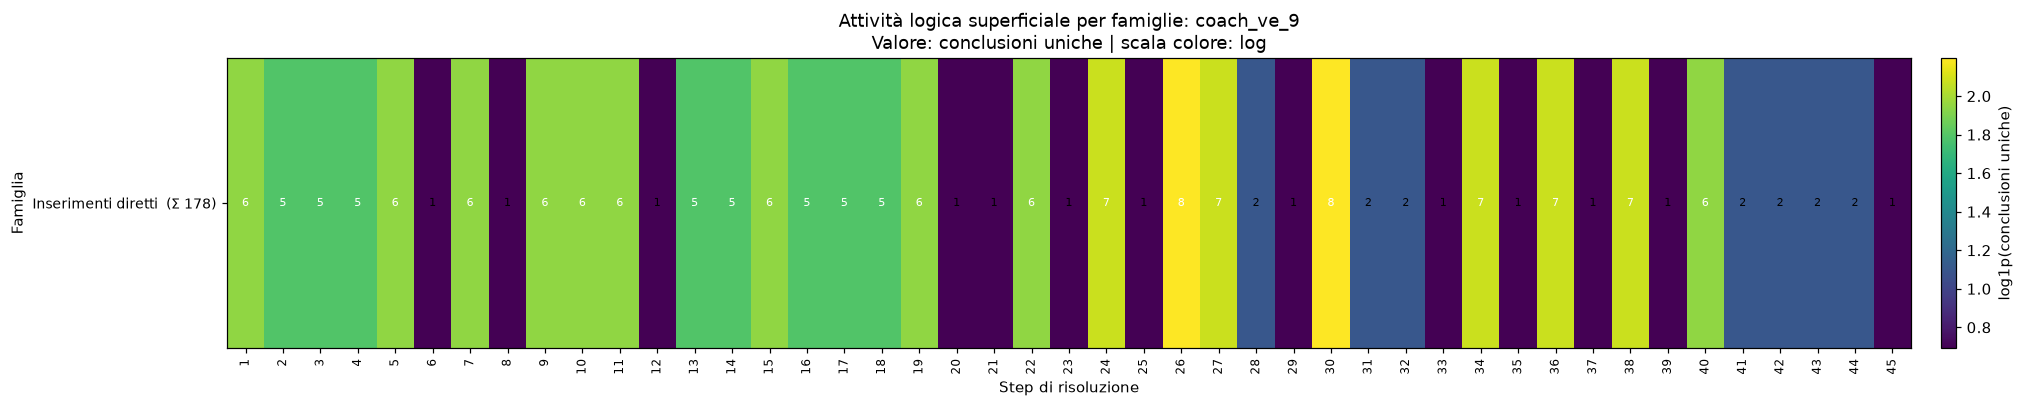

depth=superficial, view=compact


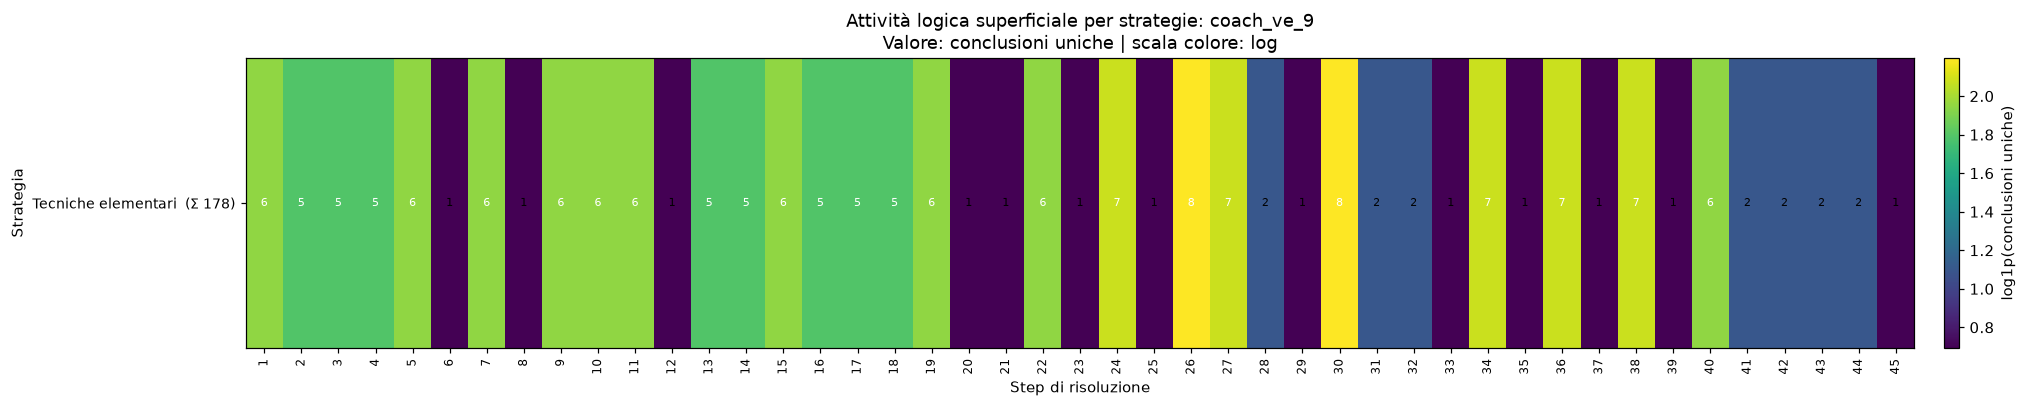

In [18]:
core_heatmaps = [
    ("deep", "extended"),
    ("deep", "compact"),
    ("superficial", "extended"),
    ("superficial", "compact"),
]

heatmap_dataframes = {}

for depth, view in core_heatmaps:
    print(f"depth={depth}, view={view}")

    heatmap_dataframes[(depth, view)] = (
        sv.technique_activity_dataframe(
            deep_result,
            depth=depth,
            view=view,
            metric="conclusions",
        )
    )

    sv.plot_technique_activity(
        deep_result,
        depth=depth,
        view=view,
        metric="conclusions",
        scale="log",
        annotate="auto",
    )


## 15. Riepilogo numerico delle heatmap


In [19]:
heatmap_rows = []

for (depth, view), dataframe in heatmap_dataframes.items():
    values = dataframe.to_numpy()
    heatmap_rows.append({
        "depth": depth,
        "view": view,
        "righe": dataframe.shape[0],
        "step": dataframe.shape[1],
        "somma": int(values.sum()) if values.size else 0,
        "massimo": int(values.max()) if values.size else 0,
        "righe_attive": int((dataframe.sum(axis=1) > 0).sum()),
    })

summary_heatmaps = pd.DataFrame(heatmap_rows)
display(summary_heatmaps)

for key, dataframe in heatmap_dataframes.items():
    print("\n", key)
    display(
        dataframe.assign(totale=dataframe.sum(axis=1))
        .sort_values("totale", ascending=False)
        .head(20)
    )


,depth,view,righe,step,somma,massimo,righe_attive
0,deep,extended,13,45,4723,67,13
1,deep,compact,8,45,4723,86,8
2,superficial,extended,1,45,178,8,1
3,superficial,compact,1,45,178,8,1



 ('deep', 'extended')


Step,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,totale
Famiglia,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Sottoinsiemi bloccati,67,64,64,67,67,63,64,62,58,57,57,52,51,46,43,42,38,37,34,33,33,31,28,24,24,22,20,20,17,13,13,13,13,10,8,7,6,3,3,0,0,0,0,0,0,1374
Catene forzanti,37,37,33,27,39,36,35,35,33,31,28,27,24,24,43,45,44,48,40,39,39,38,39,10,21,11,9,9,11,9,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,910
Inserimenti diretti,16,15,15,14,16,16,16,16,16,16,15,14,13,14,15,16,17,16,17,17,16,16,16,16,16,16,15,14,15,15,14,13,12,11,11,10,9,8,7,6,5,4,3,2,1,581
Forcing dinamici,27,27,26,26,25,25,28,25,25,25,25,25,25,20,1,0,0,0,0,0,0,0,0,19,4,15,15,8,8,8,4,8,8,8,4,4,0,0,0,0,0,0,0,0,0,468
Intersezioni box/linee,19,18,14,14,17,19,15,19,14,16,14,11,10,10,10,10,10,14,15,12,12,10,6,4,4,4,4,4,4,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,337
Forcing multipli,28,28,29,33,22,20,18,18,18,18,18,18,18,17,13,12,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,335
Assunzioni logiche,12,10,10,10,7,8,5,5,3,3,3,4,2,4,1,1,3,1,2,3,2,2,1,9,3,7,7,12,6,6,8,12,11,9,11,9,11,9,8,6,5,4,3,2,1,261
Fish,15,14,10,10,11,10,9,9,10,11,9,6,6,5,8,6,6,8,9,6,6,5,2,2,2,2,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,202
Pattern a cifra singola,5,5,4,4,7,5,4,5,5,6,6,3,5,5,6,4,4,6,7,6,6,5,2,1,1,1,1,1,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,124



 ('deep', 'compact')


Step,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,totale
Strategia,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Sottoinsiemi e intersezioni,86,82,78,81,84,82,79,81,72,73,71,63,61,56,53,52,48,51,49,45,45,41,34,28,28,26,24,24,21,15,15,13,13,10,8,7,6,3,3,0,0,0,0,0,0,1711
Catene statiche,38,38,34,28,40,37,36,36,34,32,29,27,24,24,45,45,44,48,43,39,39,38,39,10,28,11,9,9,11,9,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,933
Forcing multipli,40,38,39,43,29,28,23,23,21,21,21,22,20,21,14,13,10,1,2,3,2,2,1,9,3,7,7,12,6,6,8,12,11,9,11,9,11,9,8,6,5,4,3,2,1,596
Tecniche elementari,16,15,15,14,16,16,16,16,16,16,15,14,13,14,15,16,17,16,17,17,16,16,16,16,16,16,15,14,15,15,14,13,12,11,11,10,9,8,7,6,5,4,3,2,1,581
Forcing dinamici,27,27,26,26,25,25,28,25,25,25,25,25,25,20,1,0,0,0,0,0,0,0,0,19,4,15,15,8,8,8,4,8,8,8,4,4,0,0,0,0,0,0,0,0,0,468
Fish e wings,24,22,17,17,18,18,15,15,16,17,15,11,11,10,13,6,6,8,9,6,6,5,2,2,2,2,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,298
Pattern a cifra singola,5,5,4,4,7,5,4,5,5,6,6,3,5,5,6,4,4,6,7,6,6,5,2,1,1,1,1,1,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,124
Unicita ed esclusione,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,2,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12



 ('superficial', 'extended')


Step,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,totale
Famiglia,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Inserimenti diretti,6,5,5,5,6,1,6,1,6,6,6,1,5,5,6,5,5,5,6,1,1,6,1,7,1,8,7,2,1,8,2,2,1,7,1,7,1,7,1,6,2,2,2,2,1,178



 ('superficial', 'compact')


Step,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,totale
Strategia,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Tecniche elementari,6,5,5,5,6,1,6,1,6,6,6,1,5,5,6,5,5,5,6,1,1,6,1,7,1,8,7,2,1,8,2,2,1,7,1,7,1,7,1,6,2,2,2,2,1,178


## 16. Conclusioni, risultati distinti e prove


Metrica: conclusions


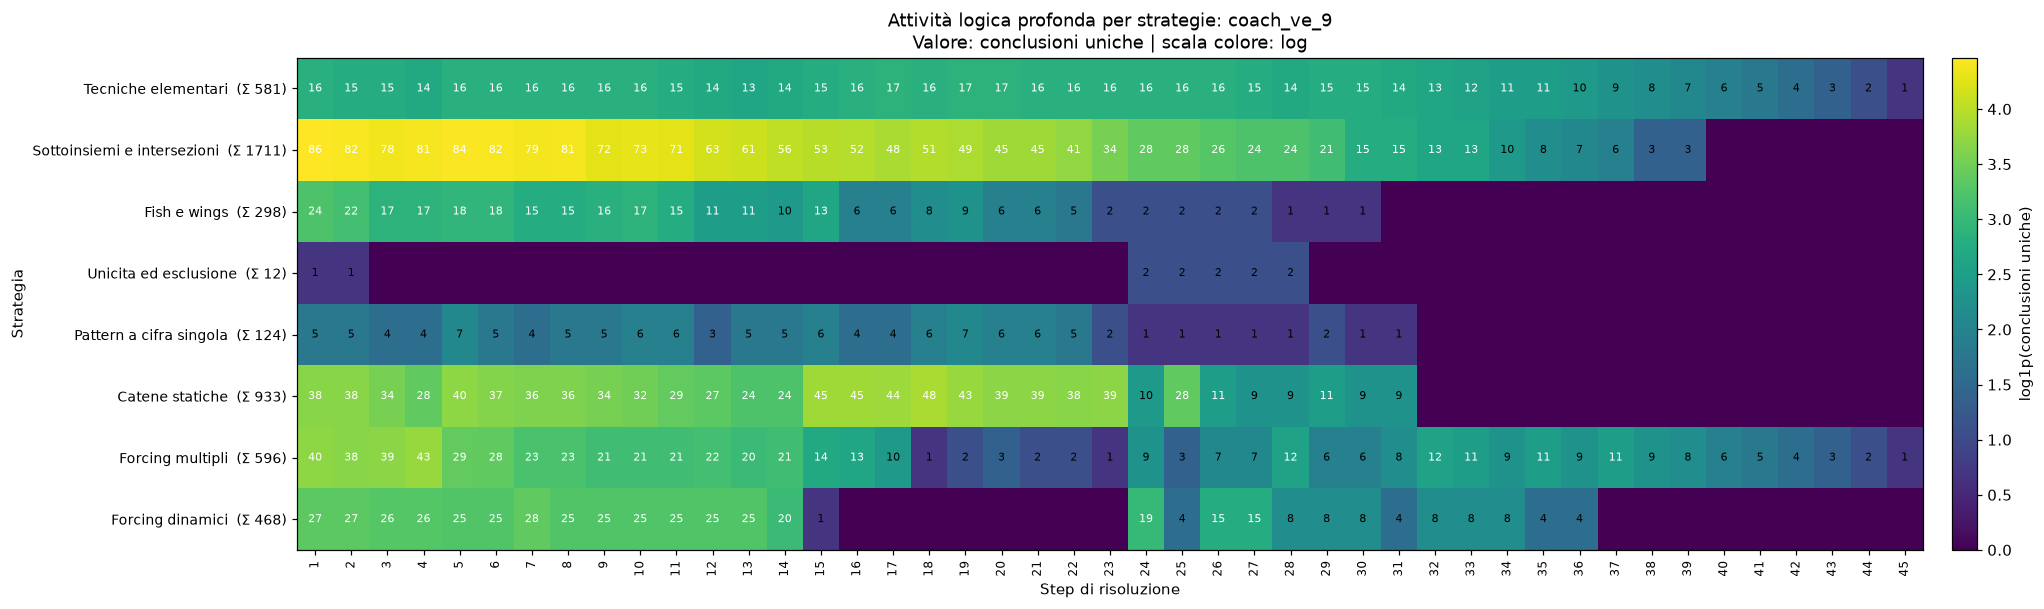

Metrica: outcomes


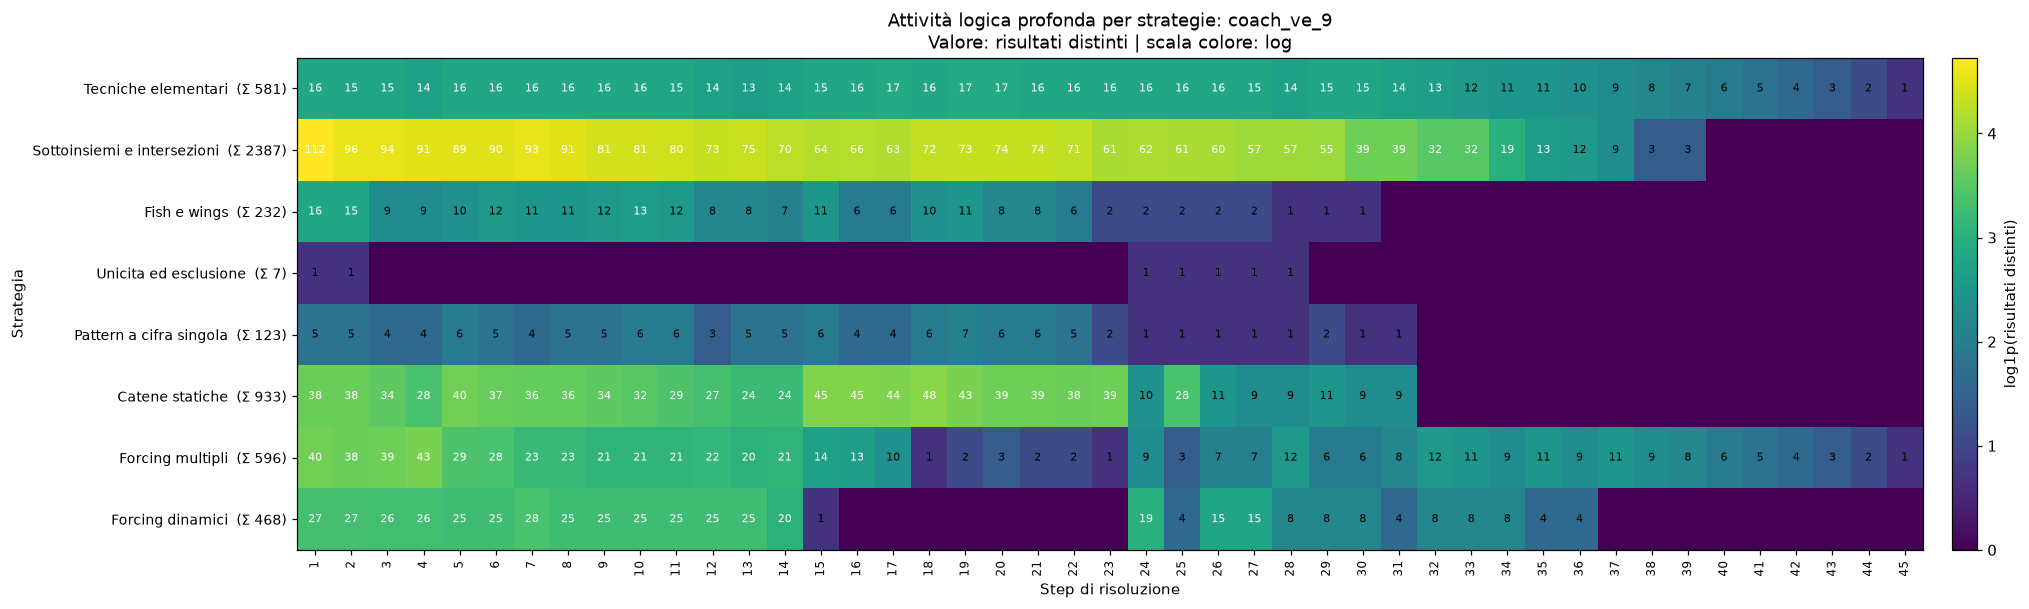

Metrica: proofs


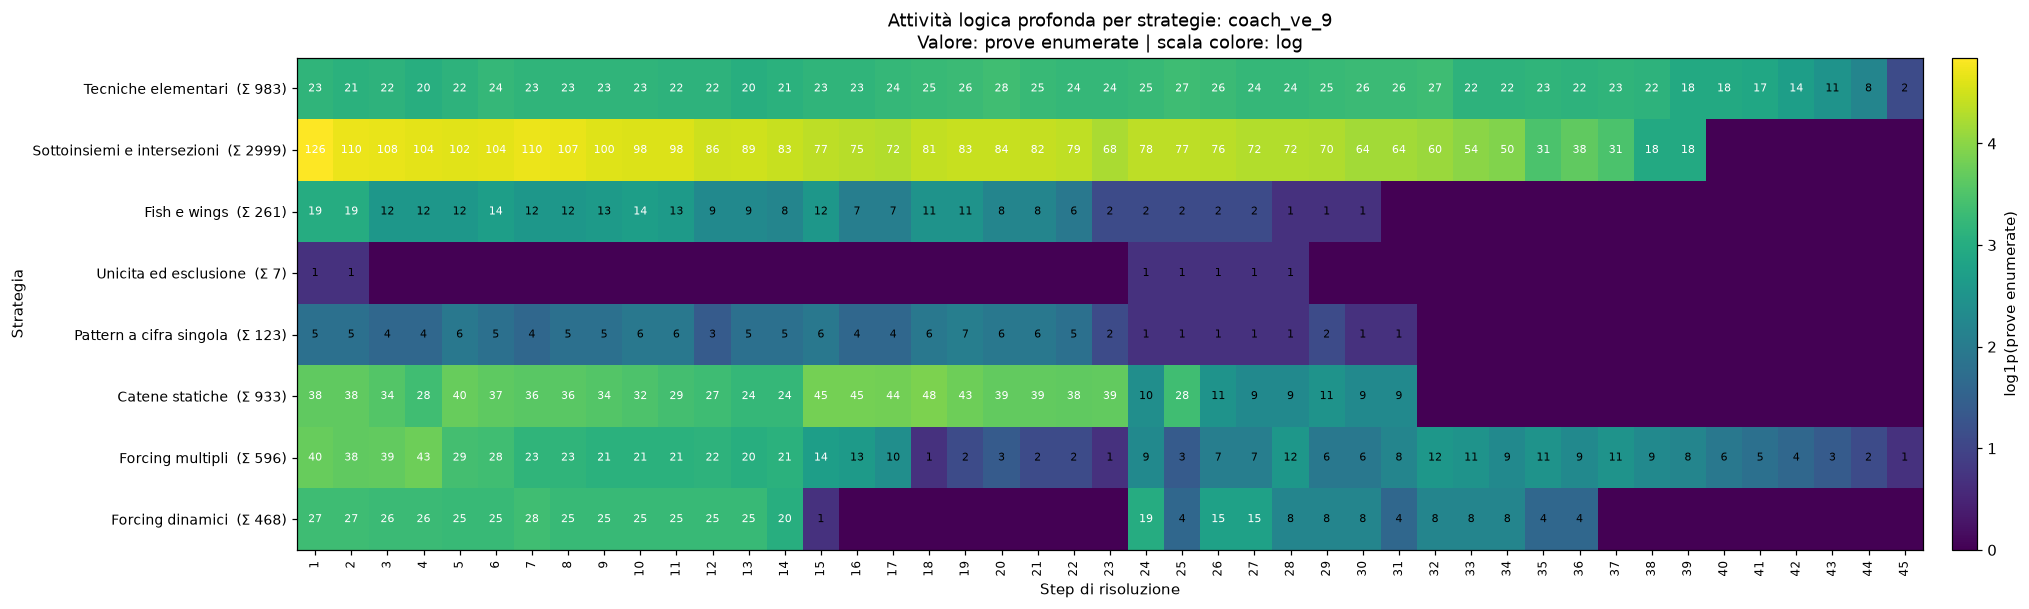

In [20]:
if RUN_ALL_METRIC_HEATMAPS:
    for metric in ("conclusions", "outcomes", "proofs"):
        print("Metrica:", metric)
        sv.plot_technique_activity(
            deep_result,
            depth="deep",
            view="compact",
            metric=metric,
            scale="log",
            annotate="auto",
        )
else:
    print("Confronto metriche disattivato.")


## 17. Scale cromatiche


Scala: log


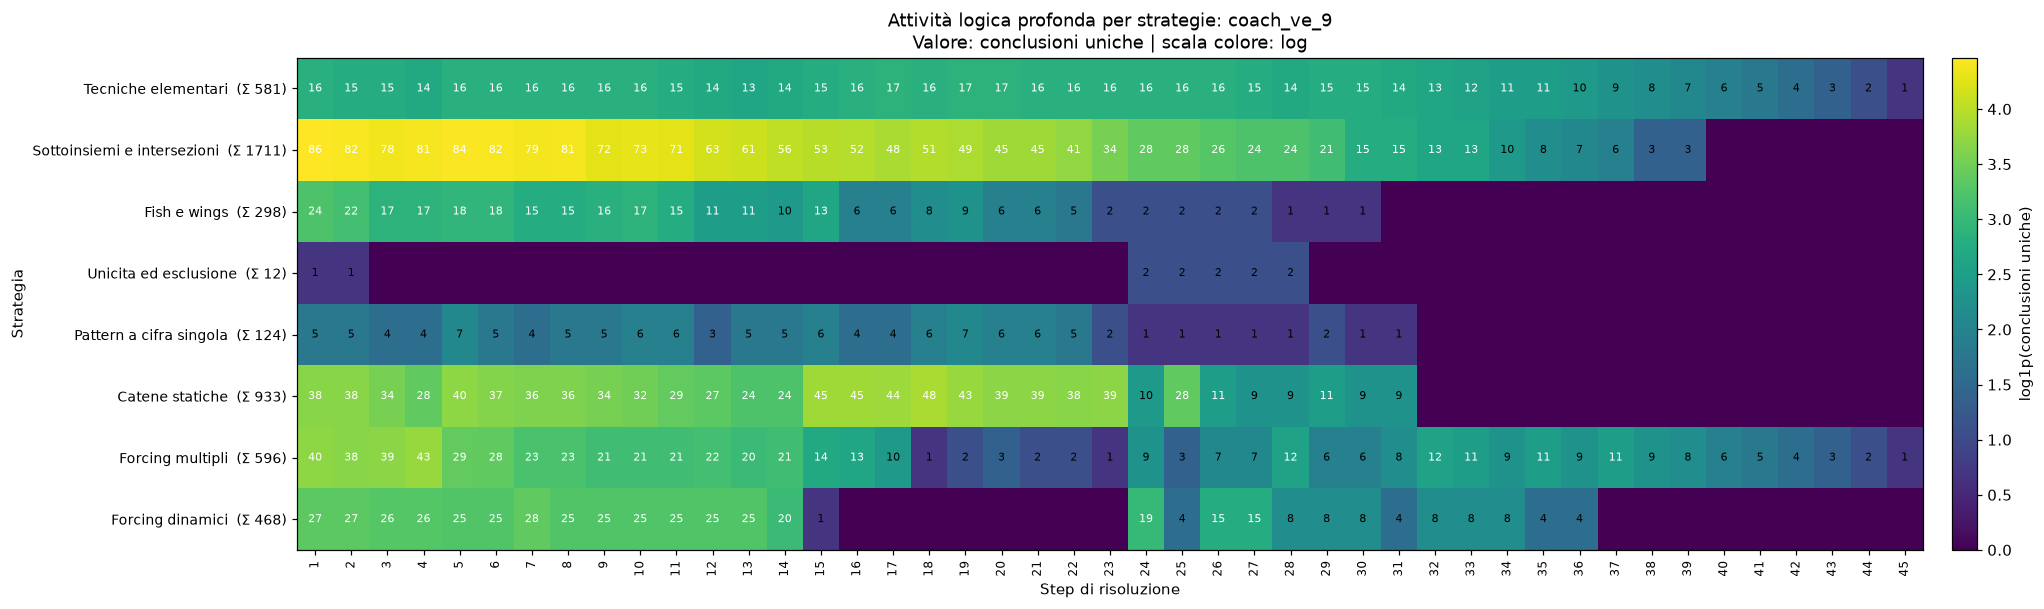

Scala: sqrt


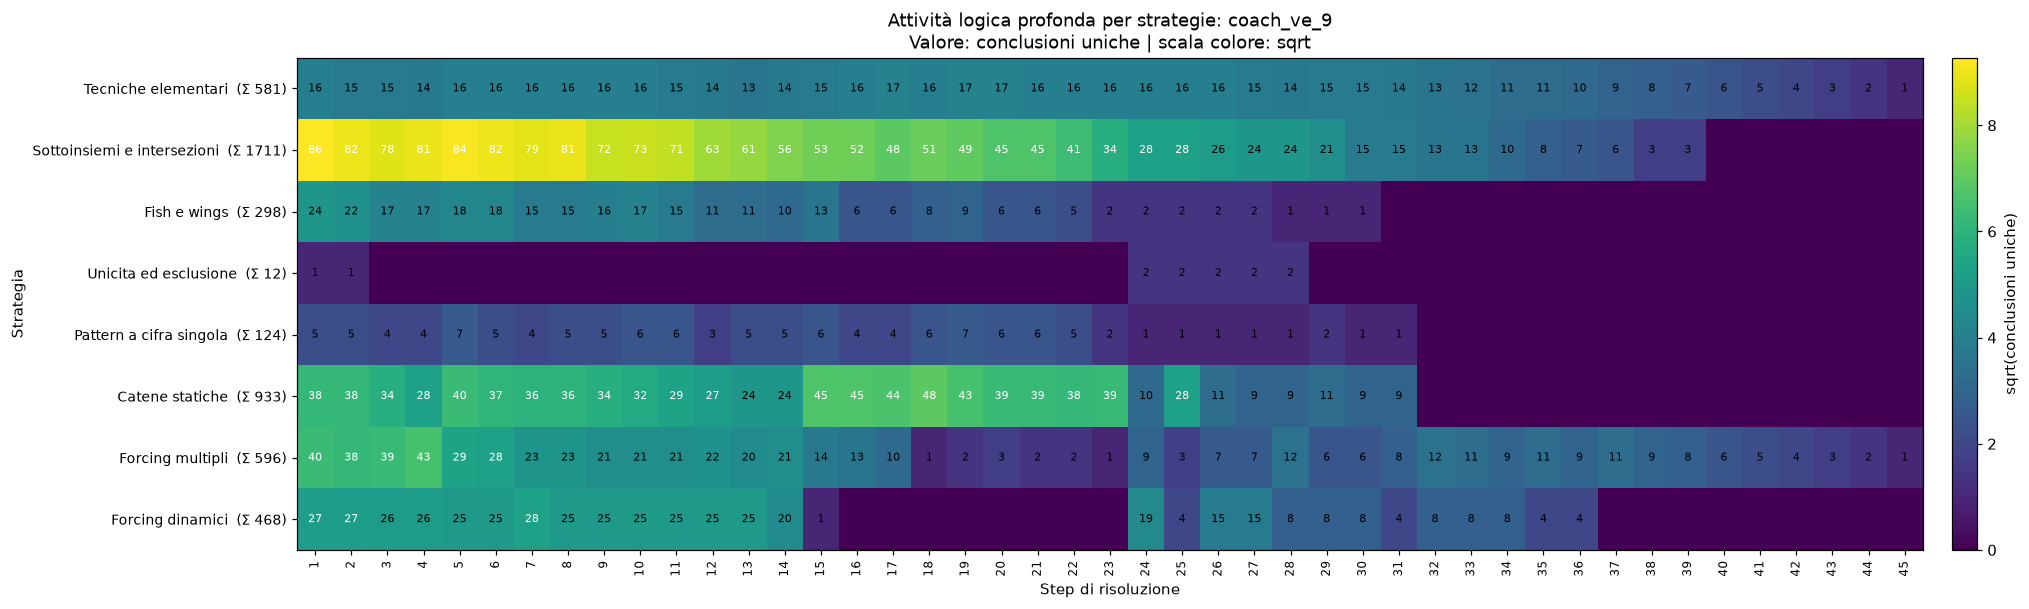

Scala: linear


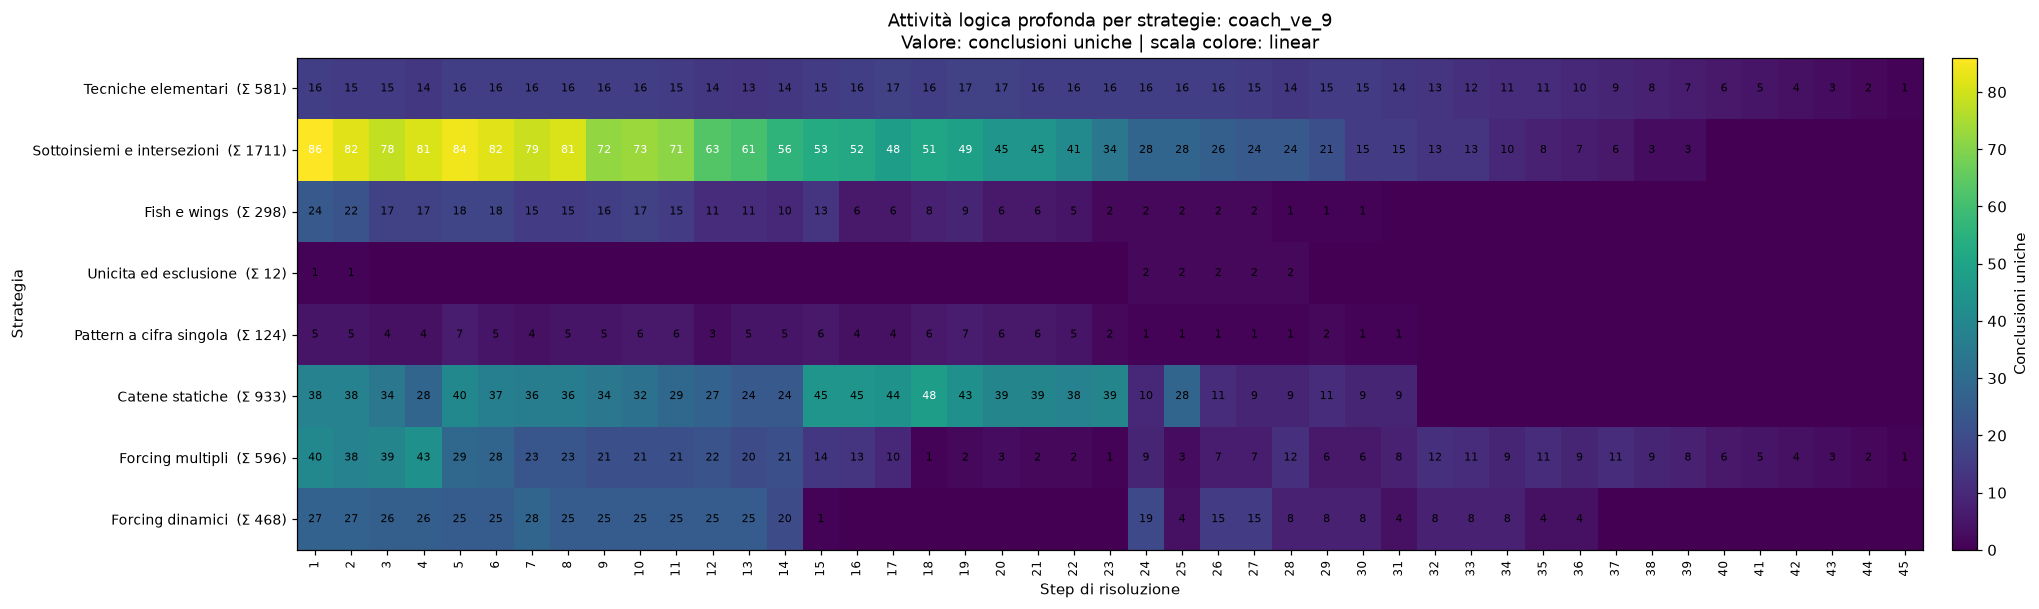

In [21]:
if RUN_ALL_SCALE_HEATMAPS:
    for scale in ("log", "sqrt", "linear"):
        print("Scala:", scale)
        sv.plot_technique_activity(
            deep_result,
            depth="deep",
            view="compact",
            metric="conclusions",
            scale=scale,
            annotate="auto",
        )
else:
    print("Confronto scale disattivato.")


## 18. Vista tecnica granulare


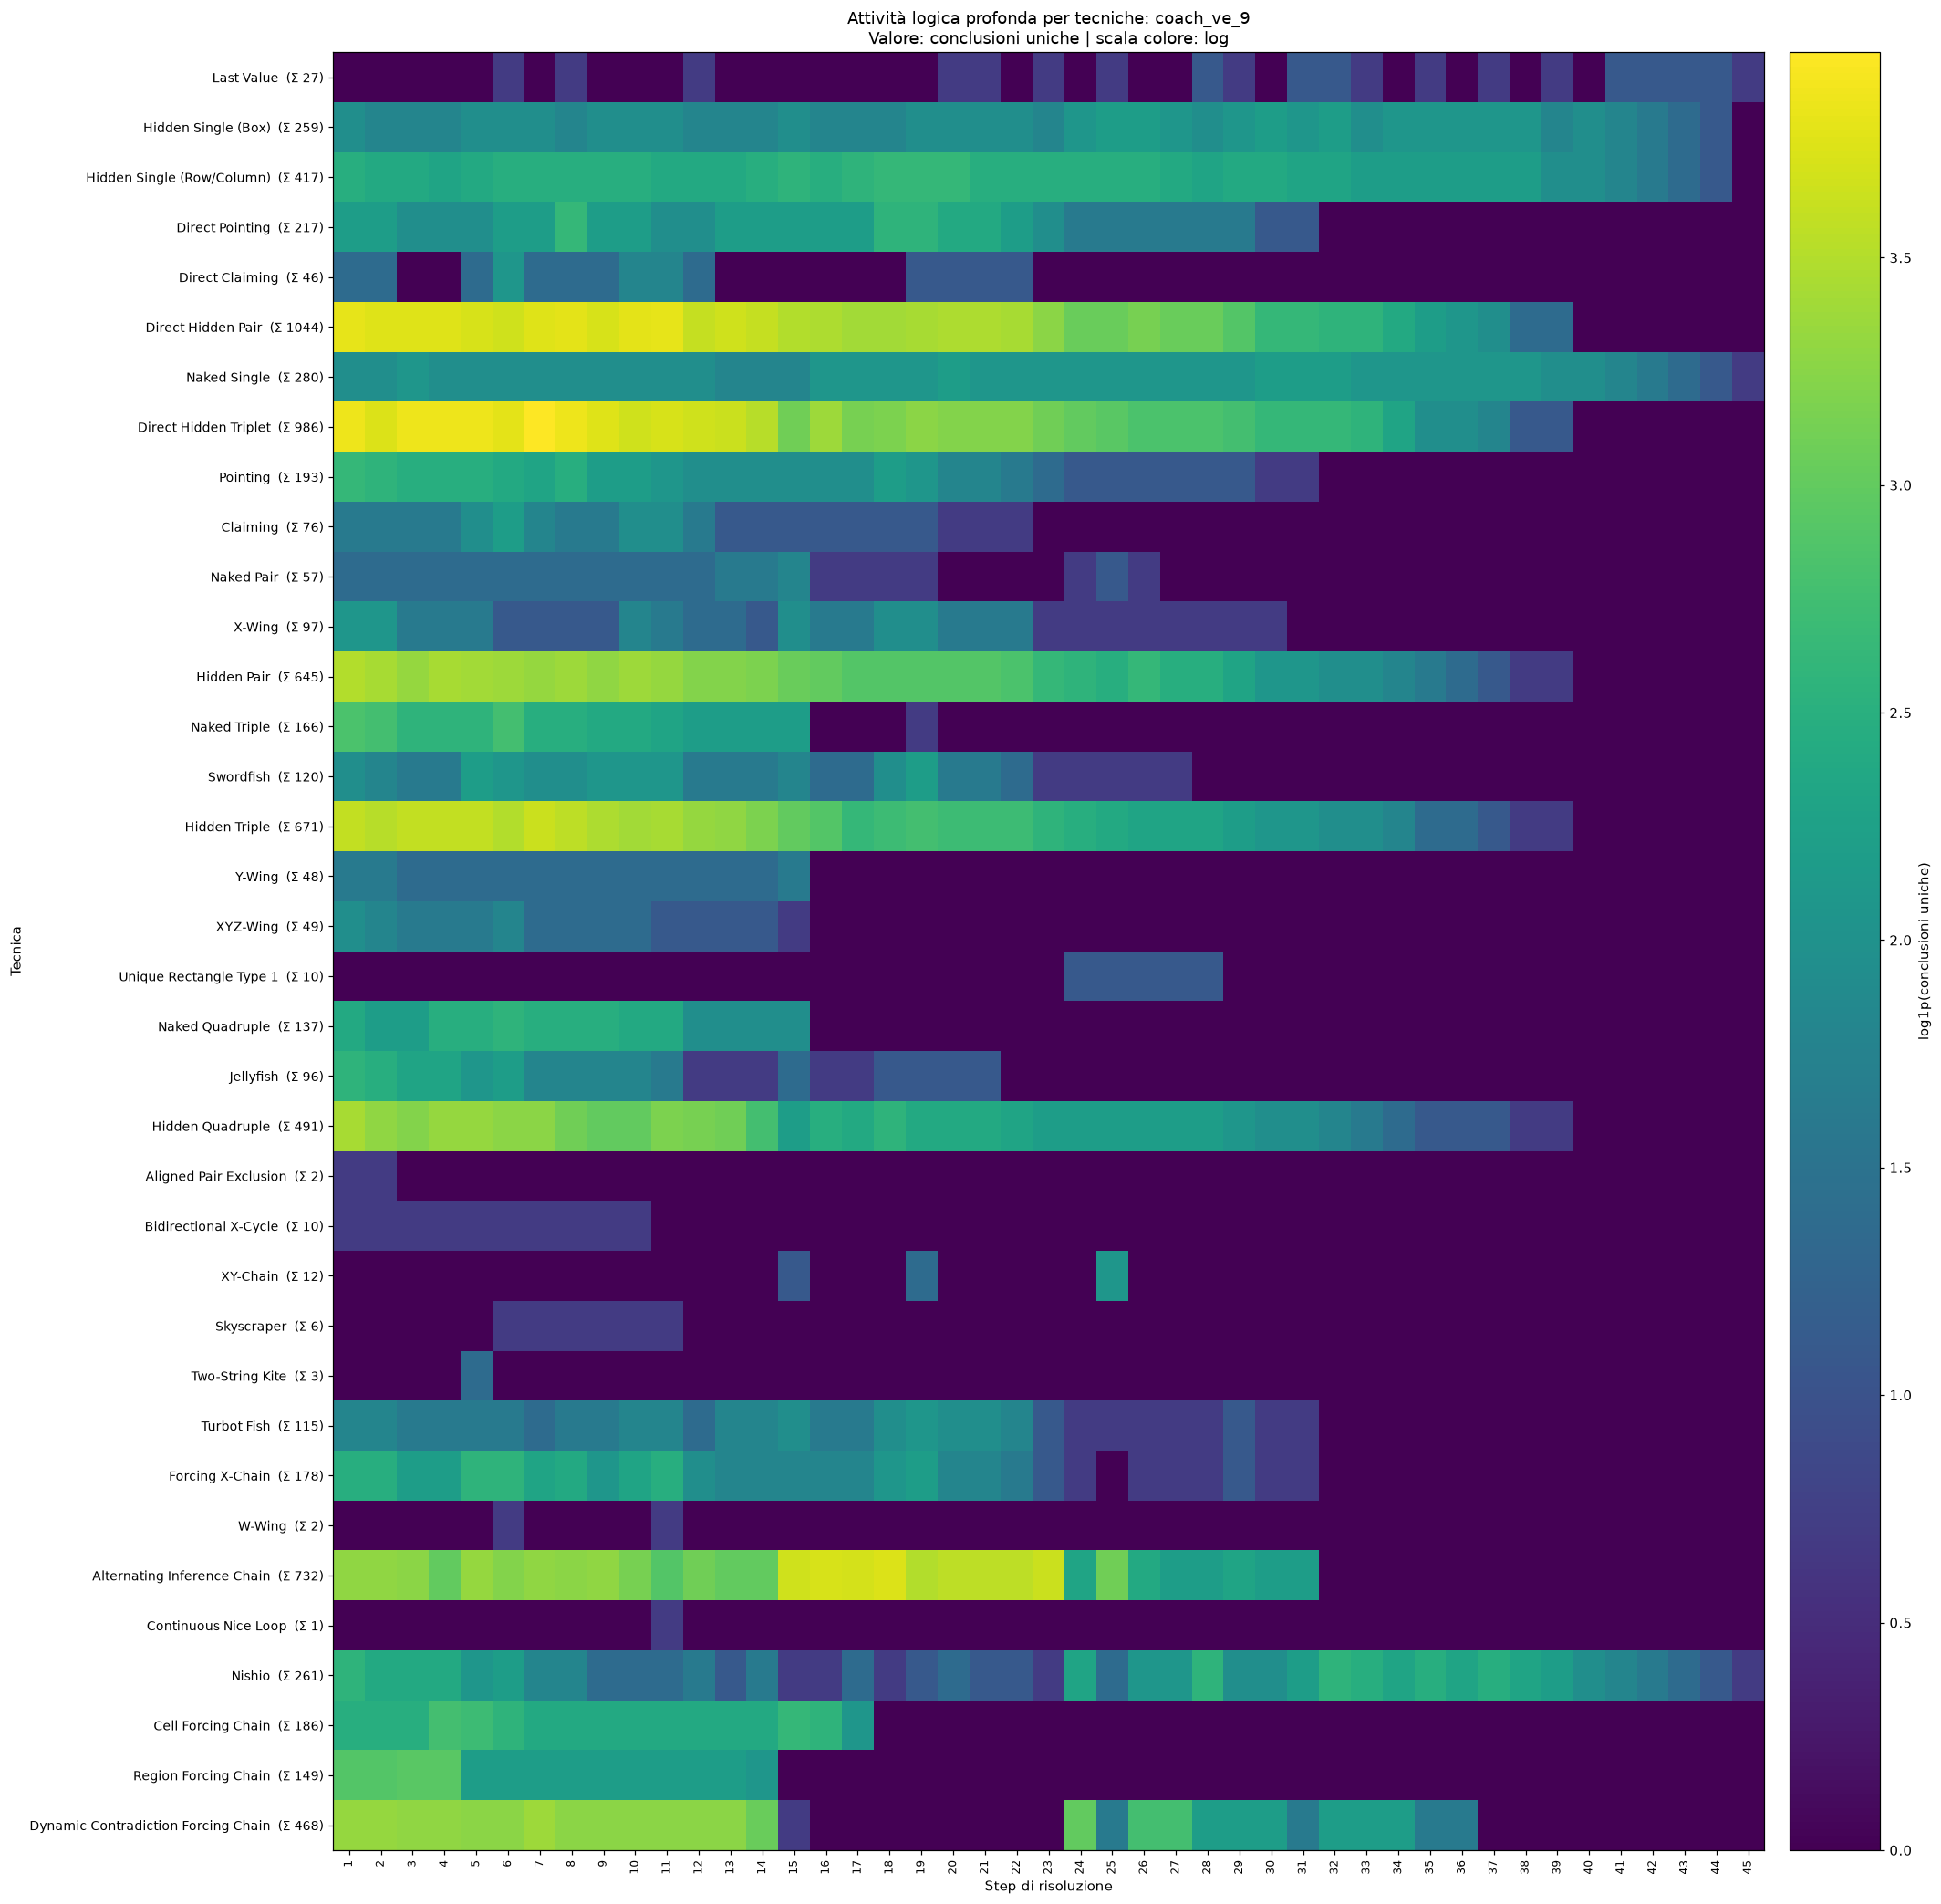

In [22]:
if RUN_TECHNIQUE_DETAIL_HEATMAP:
    sv.plot_technique_activity(
        deep_result,
        depth="deep",
        view="technique",
        metric="conclusions",
        scale="log",
        annotate=False,
        show_totals=True,
    )
else:
    print("Vista tecnica disattivata.")


## 19. Inventario realmente registrato da profile e superficial

Qui `depth="deep"` significa tutto ciò che è contenuto nella singola analisi.
Per `profile` è la fascia configurata; per `superficial` è soltanto la frontiera.


Analisi salvata: profile


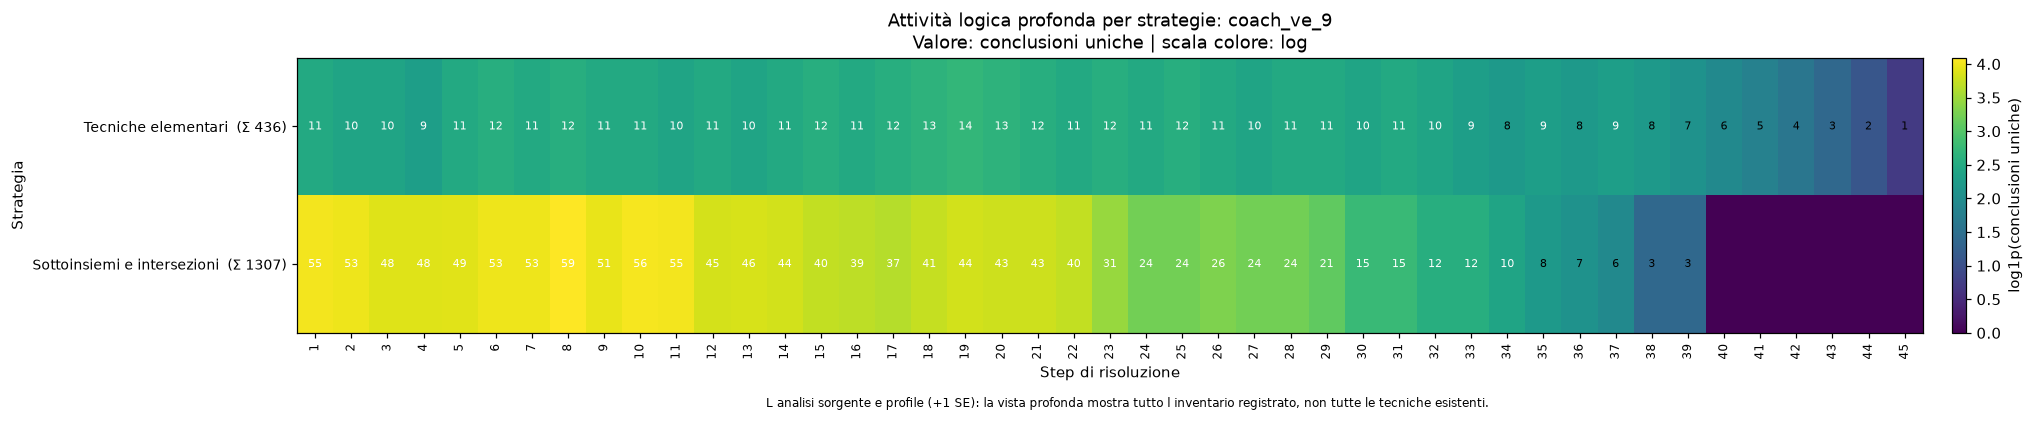

Analisi salvata: superficial


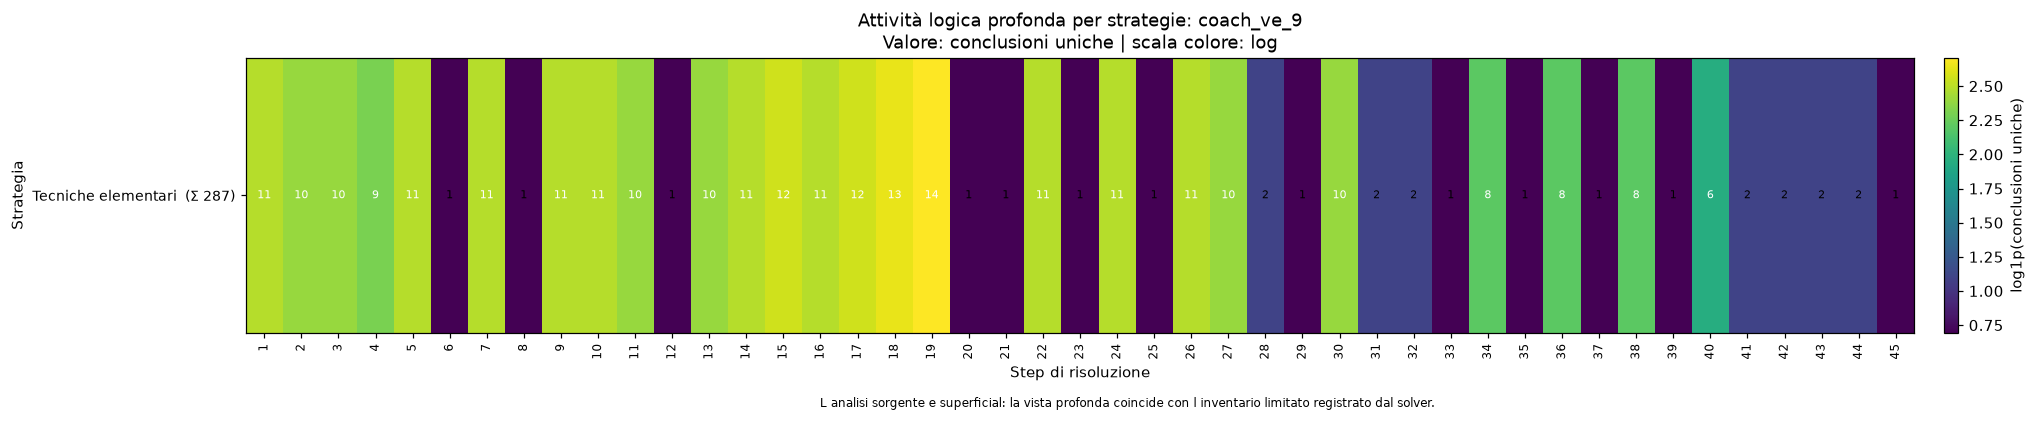

In [23]:
for mode in ("profile", "superficial"):
    result = mode_results[mode]
    print("Analisi salvata:", mode)

    sv.plot_technique_activity(
        result,
        depth="deep",
        view="compact",
        metric="conclusions",
        scale="log",
        annotate="auto",
    )


## 20. Picchi di attività logica


In [24]:
deep_compact = sv.technique_activity_dataframe(
    deep_result,
    depth="deep",
    view="compact",
    metric="conclusions",
)

if deep_compact.empty:
    print("Nessun dato di attività.")
else:
    print("Strategie più attive")
    display(
        deep_compact.sum(axis=1)
        .sort_values(ascending=False)
        .rename("conclusioni_totali")
        .to_frame()
    )

    print("Step con maggiore attività")
    display(
        deep_compact.sum(axis=0)
        .sort_values(ascending=False)
        .rename("conclusioni_totali")
        .to_frame()
        .head(15)
    )


Strategie più attive


,conclusioni_totali
Strategia,
Sottoinsiemi e intersezioni,1711
Catene statiche,933
Forcing multipli,596
Tecniche elementari,581
Forcing dinamici,468
Fish e wings,298
Pattern a cifra singola,124
Unicita ed esclusione,12


Step con maggiore attività


,conclusioni_totali
Step,
1,237
2,228
5,219
3,213
4,213
6,211
7,201
8,201
10,190


## 21. Riepilogo delle tre analisi


In [25]:
display(
    sv.analyses_summary_dataframe([
        mode_results["deep"],
        mode_results["profile"],
        mode_results["superficial"],
    ])
)


,nome,stato,modalita_analisi,finestra_profile,difficolta,carico,difficolta_percepita,difficolta_massima,numero_step,conclusioni_totali_osservate,prove_totali_osservate,step_non_banali,step_avanzati,solvibile_verificato,id
0,coach_ve_9,solved,deep,NaN,Fondamentale,0,1.661741,1.2,45,2112,6370,0,0,True,2bda79ebfd83a5879aa2
1,coach_ve_9,solved,profile,1.0,Fondamentale,0,1.661741,1.2,45,1385,1380,0,0,True,2bda79ebfd83a5879aa2
2,coach_ve_9,solved,superficial,NaN,Fondamentale,0,1.661741,1.2,45,287,436,0,0,True,2bda79ebfd83a5879aa2


## 22. Galleria delle modalità


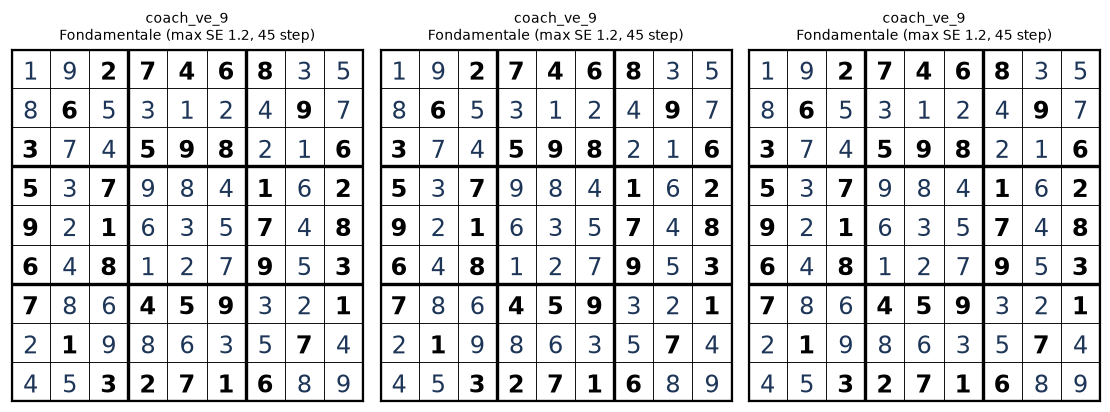

(<Figure size 1122x440 with 3 Axes>,
 array([<Axes: title={'center': 'coach_ve_9\nFondamentale (max SE 1.2, 45 step)'}>,
        <Axes: title={'center': 'coach_ve_9\nFondamentale (max SE 1.2, 45 step)'}>,
        <Axes: title={'center': 'coach_ve_9\nFondamentale (max SE 1.2, 45 step)'}>],
       dtype=object))

In [26]:
sv.gallery(
    [
        mode_results["deep"],
        mode_results["profile"],
        mode_results["superficial"],
    ],
    solved=True,
    ncols=3,
)


## 23. Batch opzionale dell archivio

Anche il batch passa da `analyse_puzzle_cached`, quindi riutilizza le analisi
deep già presenti e salva quelle mancanti.


In [27]:
if RUN_ARCHIVE_BATCH:
    references = sa.list_sudokus(
        number=ARCHIVE_BATCH_LIMIT,
        method="latest",
    )
    batch_results = []

    for reference in references:
        try:
            analysis = sa.analyse_puzzle_cached(
                reference["id"],
                analysis_mode="deep",
                force=False,
            )
            batch_results.append(analysis)
        except Exception as error:
            print(
                reference["name"],
                type(error).__name__,
                error,
            )

    if batch_results:
        display(
            sv.analyses_summary_dataframe(batch_results)
            .sort_values(
                "difficolta_massima",
                ascending=False,
            )
        )
else:
    print("Batch archivio disattivato.")


Batch archivio disattivato.


## 24. Controlli finali


In [28]:
assert chain_signature(mode_results["deep"]) == chain_signature(
    mode_results["profile"]
)
assert chain_signature(mode_results["deep"]) == chain_signature(
    mode_results["superficial"]
)

assert all(
    step["n_proofs"] >= step["n_distinct_outcomes"]
    for step in deep_result["chain"]
)
assert all(
    step["n_conclusions"] >= 1
    for step in deep_result["chain"]
)

final_row = pd.DataFrame(
    sa.list_sudokus(method="all")
)
final_row = final_row[final_row["id"] == puzzle_reference]

assert not final_row.empty
assert bool(final_row.iloc[0]["analysed_deep"])
assert bool(final_row.iloc[0]["analysed_profile"])
assert bool(final_row.iloc[0]["analysed_superficial"])

print("TUTTI I CONTROLLI FINALI SONO STATI SUPERATI.")


TUTTI I CONTROLLI FINALI SONO STATI SUPERATI.


## File prodotti dall archivio

Per ogni Sudoku la struttura attesa è simile a:

```text
sudoku_data/
    puzzles/
        <puzzle_id>.json
    analyses/
        <puzzle_id>/
            analysis.json
            analysis_profile_1.json
            analysis_superficial.json
```

Una finestra profile diversa genera una variante diversa, per esempio
`analysis_profile_0p5.json`, senza cancellare quella con finestra 1.0.
